# Exploring a single replay (`ReplayData` instance)

In [2]:
import os
from dotenv import load_dotenv
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np

from impulse.collection.database import ImpulseDB
from impulse.collection.s3_manager import S3Manager
from impulse.replay_dataset import ReplayDataset

load_dotenv()

True

In [3]:
x_color = 'darkcyan'
y_color = 'darkviolet'
z_color = 'darkred'

In [4]:
impulse_path = os.getenv('IMPULSE_PATH')
db_path = os.getenv('DB_PATH')

db = ImpulseDB(db_path)
s3 = S3Manager()

Database initialized: /Users/david/dev/impulse/impulse.db
✓ S3 Manager initialized (Local Credentials)
  Region: us-east-2
  Bucket: impulse-rl-4e8e-a163-3a3b24a95b2b


## `ReplayData` Instance

In [5]:
dataset = ReplayDataset(
    db_path = db_path,
    s3_manager = s3
)

replay = dataset.load_sample(1, seed=117)[0]

Found 7282 parsed replays in database
Loaded 1/1 replays


In [6]:
type(replay)

impulse.replay_dataset.ReplayData

In [7]:
replay.__dict__.keys()

dict_keys(['replay_id', 'frames', 'metadata'])

In [5]:
replay.metadata

{'replay_id': '83bcee7c-6d3b-42c9-8d28-b82eb512391c',
 'frame_count': 9157,
 'feature_count': 125,
 'fps': 30.0,
 'parsed_at': '2026-03-10T21:08:35.038797+00:00',
 'source_file': '/tmp/tmp2dwcwsnb/83bcee7c-6d3b-42c9-8d28-b82eb512391c.replay',
 'ballchasing_id': '6ECBD321475ECAF06639228387CA76B9',
 'replay_name': 'NA G C9 vs DIG G1 2024-05-24.13.06',
 'date': '2024-05-24 13-06-27',
 'map': 'EuroStadium_Night_P',
 'match_type': 'Private',
 'team_size': 3,
 'num_frames': 9800,
 'duration_seconds': 305.23333333333335,
 'team_0_score': None,
 'team_1_score': 3,
 'goals': [{'PlayerName': 'Arsenal', 'PlayerTeam': 1, 'frame': 1363},
  {'PlayerName': 'stizzy', 'PlayerTeam': 1, 'frame': 4788},
  {'PlayerName': 'Gyro.', 'PlayerTeam': 1, 'frame': 9710}],
 'highlights': [{'BallName': 'Ball_TA_16',
   'CarName': 'Car_TA_54',
   'GoalActorName': 'None',
   'frame': 441},
  {'BallName': 'Ball_TA_16',
   'CarName': 'Car_TA_52',
   'GoalActorName': 'None',
   'frame': 607},
  {'BallName': 'Ball_TA_16',


In [6]:
frames = replay.frames 
print(frames.shape)

(9157, 125)


In [7]:
frames.columns.tolist()

['frame',
 'current time',
 'frame time',
 'seconds remaining',
 'Ball - position x',
 'Ball - position y',
 'Ball - position z',
 'Ball - linear velocity x',
 'Ball - linear velocity y',
 'Ball - linear velocity z',
 'Ball - angular velocity x',
 'Ball - angular velocity y',
 'Ball - angular velocity z',
 'Ball - quaternion x',
 'Ball - quaternion y',
 'Ball - quaternion z',
 'Ball - quaternion w',
 'p0_position x',
 'p0_position y',
 'p0_position z',
 'p0_linear velocity x',
 'p0_linear velocity y',
 'p0_linear velocity z',
 'p0_angular velocity x',
 'p0_angular velocity y',
 'p0_angular velocity z',
 'p0_quaternion x',
 'p0_quaternion y',
 'p0_quaternion z',
 'p0_quaternion w',
 'p0_boost level',
 'p0_dodge active',
 'p0_jump active',
 'p0_double jump active',
 'p0_player demolished by',
 'p1_position x',
 'p1_position y',
 'p1_position z',
 'p1_linear velocity x',
 'p1_linear velocity y',
 'p1_linear velocity z',
 'p1_angular velocity x',
 'p1_angular velocity y',
 'p1_angular velo

In [15]:
print("Player mapping:")
print("---------------")
for index in replay.player_mapping:
    print(f"p{index}: {replay.player_mapping[index]['name']}")

Player mapping:
---------------
p0: LionBlaze
p1: Zineel
p2: percy.
p3: Gyro.
p4: Arsenal
p5: stizzy


In [16]:
frames.info()

<class 'pandas.DataFrame'>
RangeIndex: 9157 entries, 0 to 9156
Columns: 125 entries, frame to p5_player demolished by
dtypes: float32(124), int64(1)
memory usage: 4.4 MB


In [17]:
frames.describe()

,frame,current time,frame time,seconds remaining,Ball - position x,Ball - position y,Ball - position z,Ball - linear velocity x,Ball - linear velocity y,Ball - linear velocity z,...,p5_angular velocity z,p5_quaternion x,p5_quaternion y,p5_quaternion z,p5_quaternion w,p5_boost level,p5_dodge active,p5_jump active,p5_double jump active,p5_player demolished by
count,9157.000000,9157.000000,9157.000000,9157.000000,9157.000000,9157.000000,9157.000000,9157.000000,9157.000000,9157.000000,...,9157.000000,9157.000000,9157.000000,9157.000000,9157.000000,9157.000000,9157.000000,9157.000000,9157.000000,9157.0
mean,4578.000000,245.209183,245.225296,150.930542,-635.989868,1393.416748,758.414490,0.691936,-47.770962,2.139181,...,9.449206,0.092840,0.054197,0.302896,0.349515,110.637871,25.343781,33.174728,6.183357,-1.0
std,2643.542541,98.183357,98.183693,86.633392,2294.132324,2872.979492,500.740051,1178.514160,1362.295898,622.719177,...,177.827591,0.293508,0.318165,0.540817,0.542920,83.494919,16.839481,22.766399,4.045033,0.0
min,0.000000,70.730148,70.743622,0.000000,-4007.600098,-5178.169922,79.980003,-3596.560059,-3417.219971,-1948.270020,...,-544.679993,-0.698297,-0.707058,-0.707101,-0.707107,0.000000,0.000000,0.000000,0.000000,-1.0
25%,2289.000000,162.836716,162.853912,76.000000,-2604.770020,-589.650024,338.079987,-915.989990,-1131.750000,-386.440002,...,-103.459999,-0.004572,-0.002981,-0.151969,-0.130924,39.000000,10.000000,14.000000,4.000000,-1.0
50%,4578.000000,254.923050,254.943253,152.000000,-1070.349976,2141.040039,672.580017,85.419998,-15.460000,0.000000,...,0.070000,-0.000542,0.003822,0.387367,0.506743,92.000000,22.000000,28.000000,6.000000,-1.0
75%,6867.000000,331.204926,331.223785,226.000000,1454.510010,3836.979980,1121.319946,804.179993,977.760010,379.619995,...,133.110001,0.146709,0.053660,0.795101,0.844947,181.000000,34.000000,48.000000,10.000000,-1.0
max,9156.000000,407.486298,407.505798,300.000000,4003.260010,5103.770020,1960.439941,3042.090088,3306.629883,2337.290039,...,549.369995,0.983055,0.994004,0.999988,1.000000,255.000000,66.000000,86.000000,14.000000,-1.0


In [26]:
total_nan_count = frames.isna().sum().sum()
total_nan_count

np.int64(0)

## Ball physics data

### Ball position

In [30]:
ball_position = frames[['Ball - position x', 'Ball - position y', 'Ball - position z']]
ball_position.columns = ['x', 'y', 'z']
ball_position.head()

,x,y,z
0,-2.82,13.270000,92.099998
1,-7.33,22.760000,112.050003
2,1.86,26.950001,123.650002
3,6.92,31.780001,125.809998
4,14.28,45.650002,127.889999


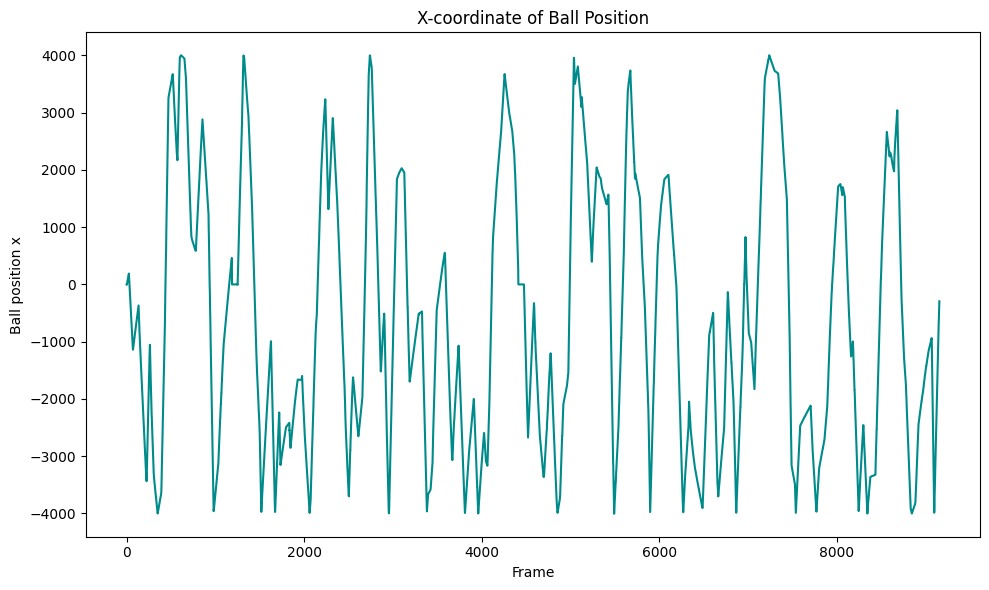

In [55]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(ball_position['x'], color=x_color)
ax.set_xlabel('Frame')
ax.set_ylabel('Ball position x')
ax.set_title('X-coordinate of Ball Position')
plt.tight_layout()
plt.show()

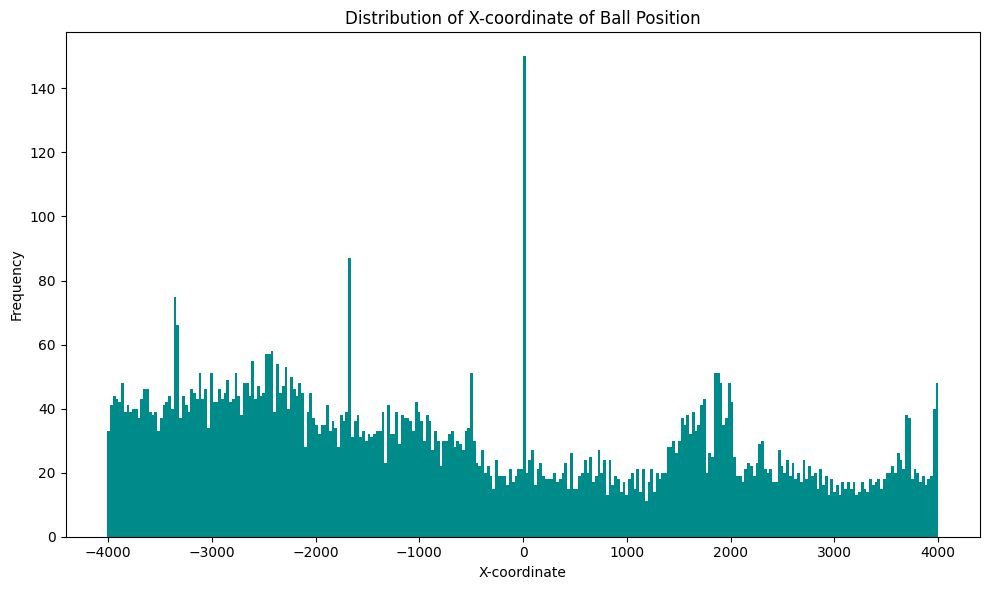

In [56]:
fig, ax = plt.subplots(figsize=(10,6))

ax.hist(ball_position['x'], bins=300, color=x_color)
ax.set_xlabel('X-coordinate')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of X-coordinate of Ball Position')
plt.tight_layout()
plt.show()

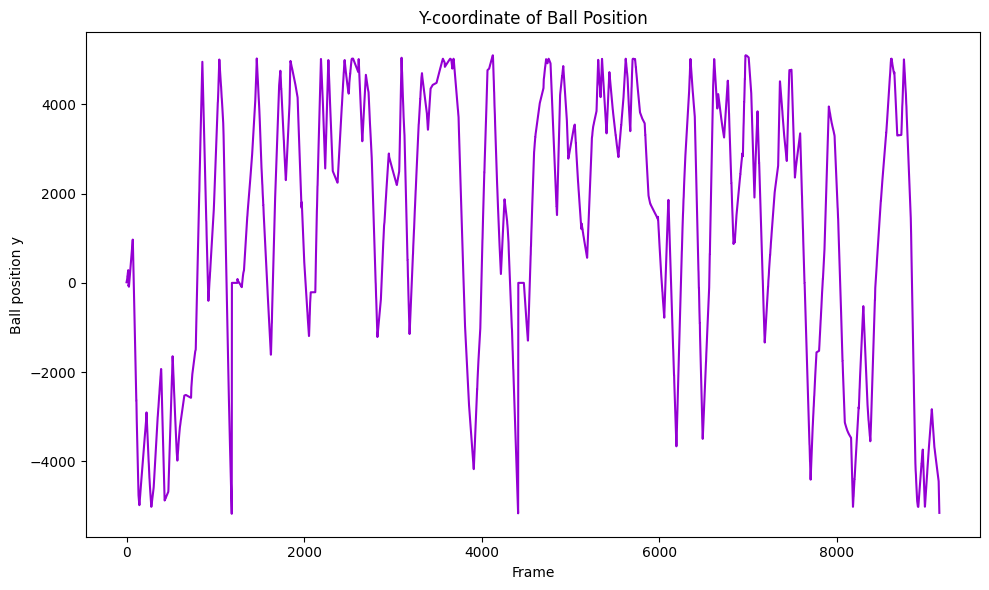

In [57]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(ball_position['y'], color=y_color)
ax.set_xlabel('Frame')
ax.set_ylabel('Ball position y')
ax.set_title('Y-coordinate of Ball Position')
plt.tight_layout()
plt.show()

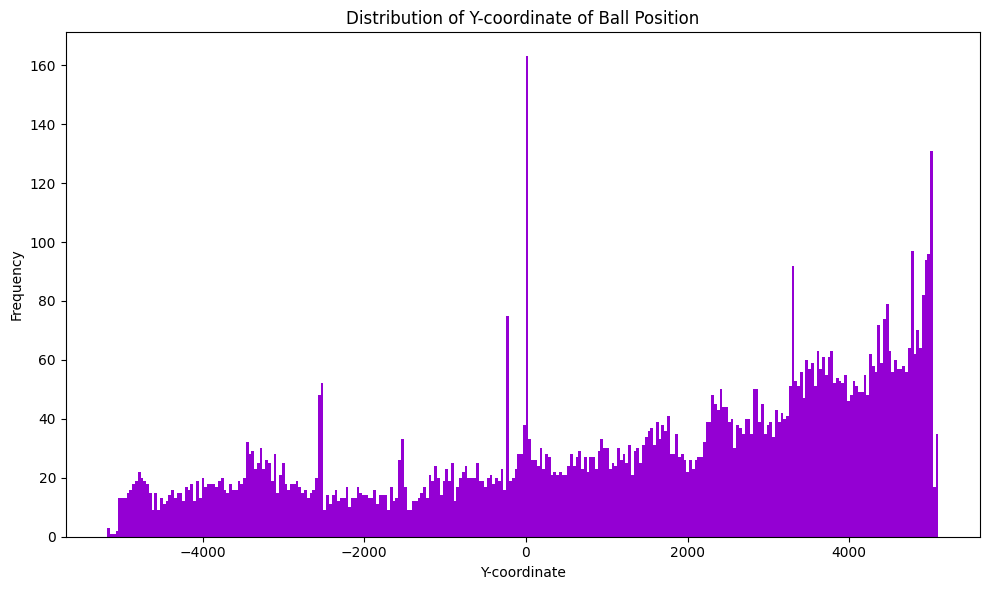

In [58]:
fig, ax = plt.subplots(figsize=(10,6))

ax.hist(ball_position['y'], bins=300, color=y_color)
ax.set_xlabel('Y-coordinate')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Y-coordinate of Ball Position')
plt.tight_layout()
plt.show()

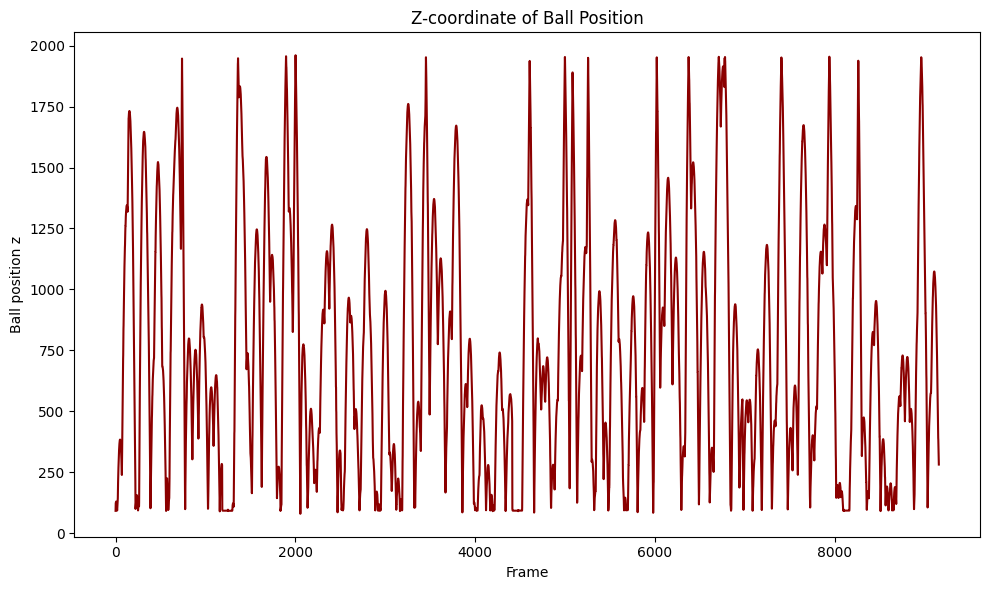

In [66]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(ball_position['z'], color=z_color)
ax.set_xlabel('Frame')
ax.set_ylabel('Ball position z')
ax.set_title('Z-coordinate of Ball Position')
plt.tight_layout()
plt.show()

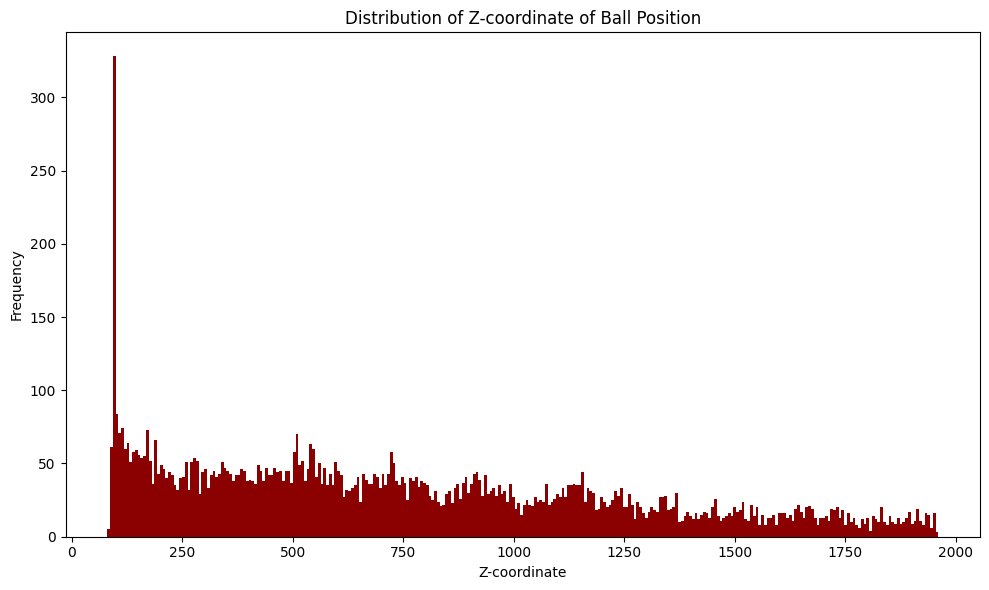

In [67]:
fig, ax = plt.subplots(figsize=(10,6))

ax.hist(ball_position['z'], bins=300, color=z_color)
ax.set_xlabel('Z-coordinate')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Z-coordinate of Ball Position')
plt.tight_layout()
plt.show()

### Ball linear velocity

In [31]:
ball_linear_velocity = frames[['Ball - linear velocity x', 'Ball - linear velocity y', 'Ball - linear velocity z']]
ball_linear_velocity.columns = ['x', 'y', 'z']
ball_linear_velocity.head()

,x,y,z
0,186.880005,765.289978,268.790009
1,157.029999,127.570000,493.920013
2,201.770004,106.589996,147.440002
3,76.940002,166.559998,59.939999
4,269.200012,499.149994,59.520000


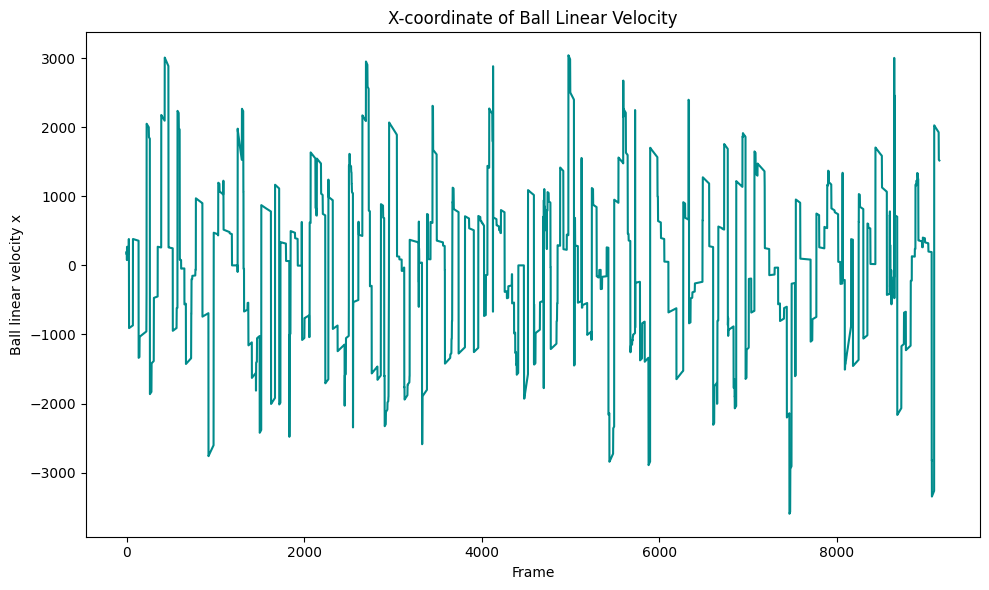

In [68]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(ball_linear_velocity['x'], color=x_color)
ax.set_xlabel('Frame')
ax.set_ylabel('Ball linear velocity x')
ax.set_title('X-coordinate of Ball Linear Velocity')
plt.tight_layout()
plt.show()

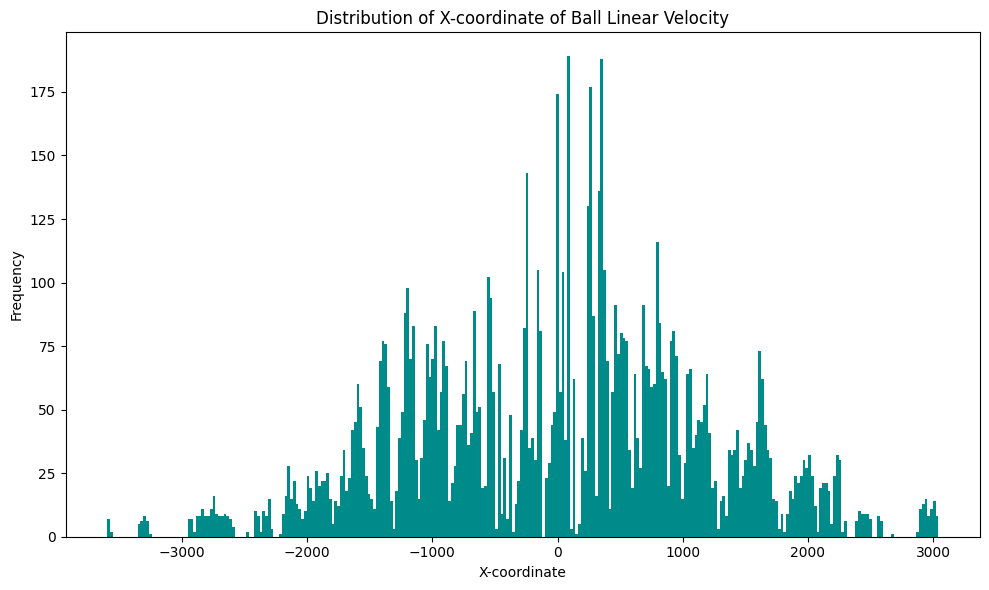

In [70]:
fig, ax = plt.subplots(figsize=(10,6))

ax.hist(ball_linear_velocity['x'], bins=300, color=x_color)
ax.set_xlabel('X-coordinate')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of X-coordinate of Ball Linear Velocity')
plt.tight_layout()
plt.show()

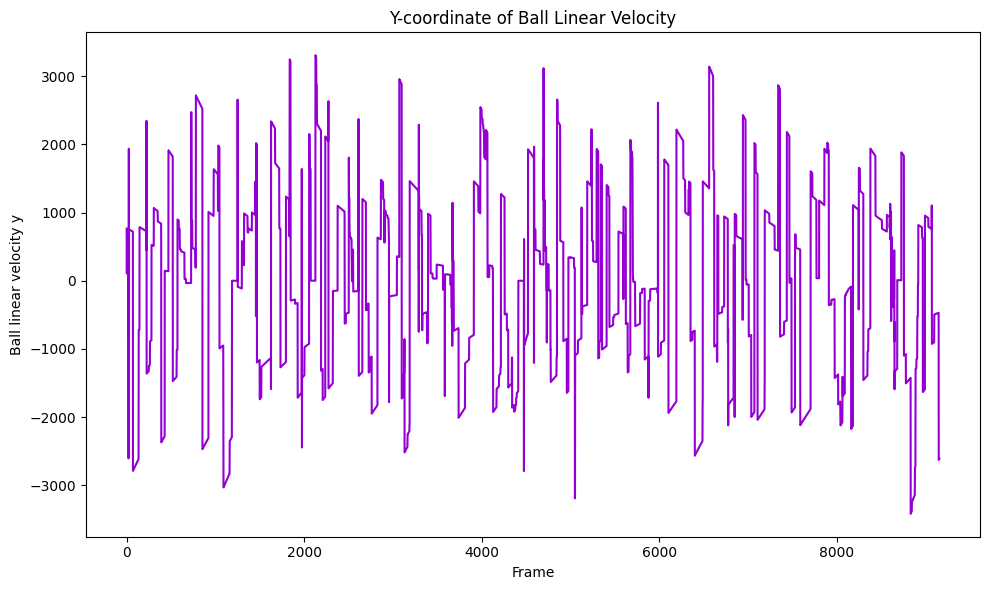

In [69]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(ball_linear_velocity['y'], color=y_color)
ax.set_xlabel('Frame')
ax.set_ylabel('Ball linear velocity y')
ax.set_title('Y-coordinate of Ball Linear Velocity')
plt.tight_layout()
plt.show()

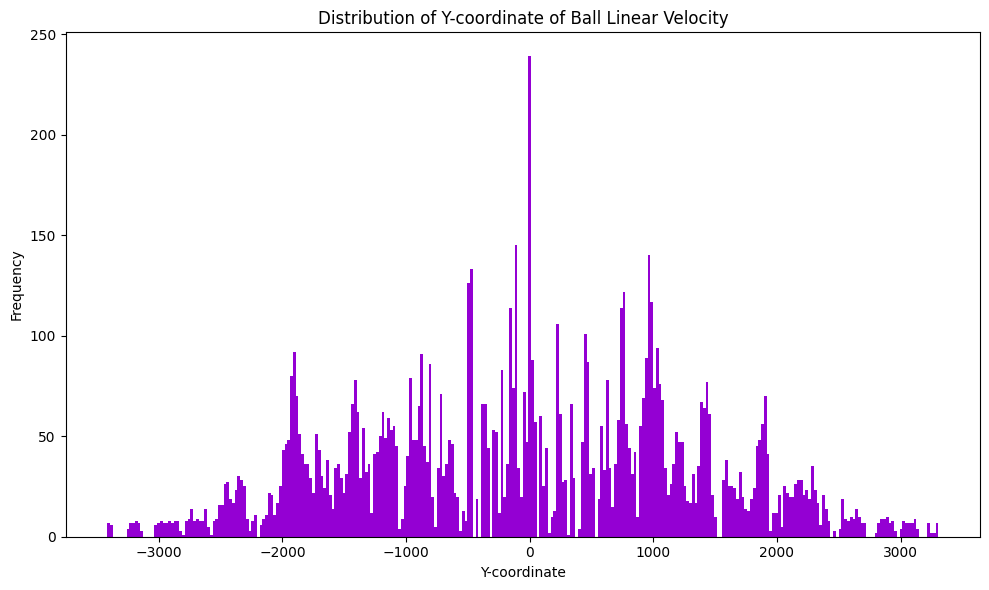

In [71]:
fig, ax = plt.subplots(figsize=(10,6))

ax.hist(ball_linear_velocity['y'], bins=300, color=y_color)
ax.set_xlabel('Y-coordinate')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Y-coordinate of Ball Linear Velocity')
plt.tight_layout()
plt.show()

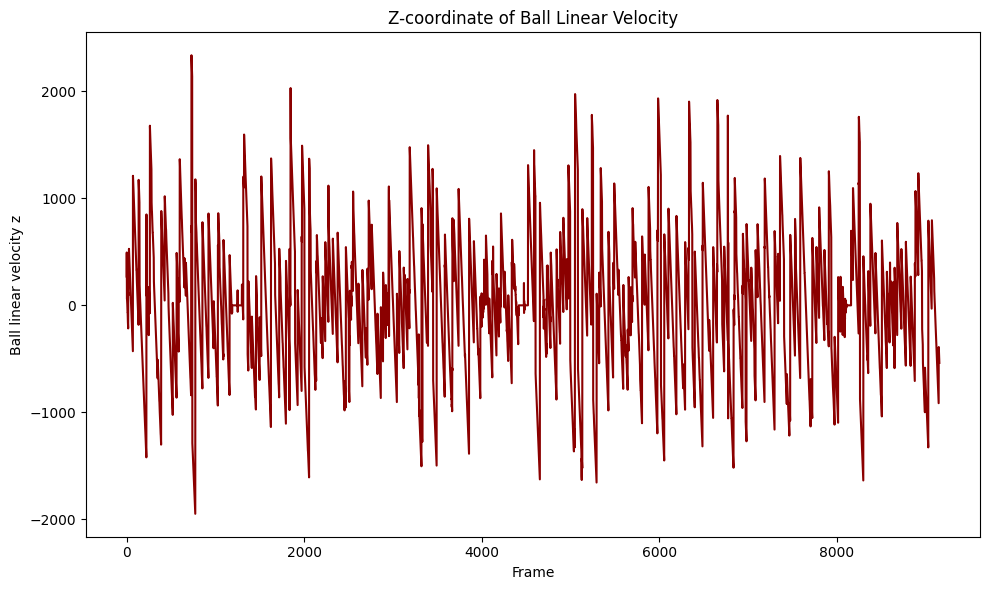

In [72]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(ball_linear_velocity['z'], color=z_color)
ax.set_xlabel('Frame')
ax.set_ylabel('Ball linear velocity z')
ax.set_title('Z-coordinate of Ball Linear Velocity')
plt.tight_layout()
plt.show()

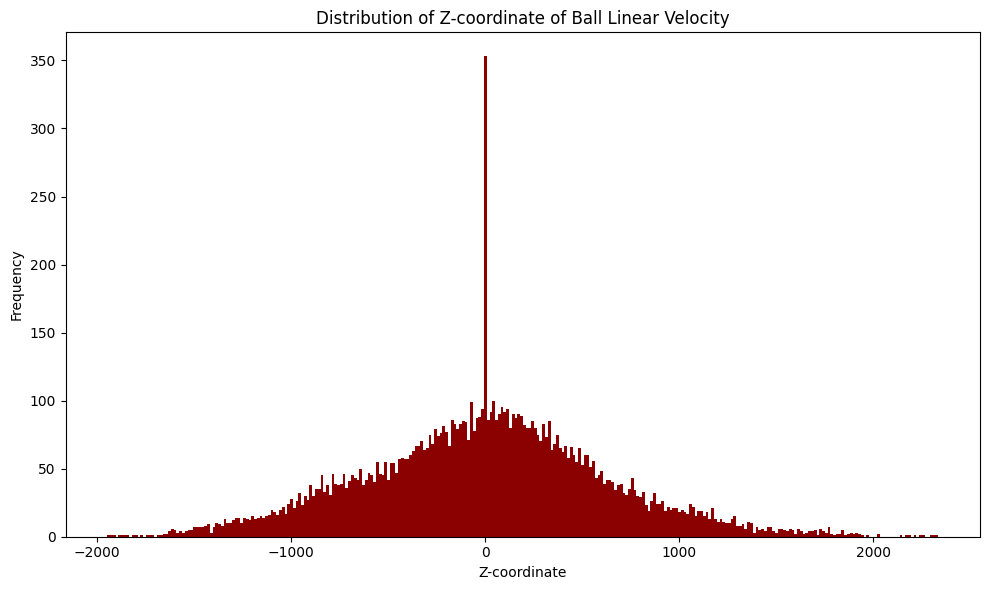

In [73]:
fig, ax = plt.subplots(figsize=(10,6))

ax.hist(ball_linear_velocity['z'], bins=300, color=z_color)
ax.set_xlabel('Z-coordinate')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Z-coordinate of Ball Linear Velocity')
plt.tight_layout()
plt.show()

### Ball speed

In [95]:
ball_speed = np.sqrt(ball_linear_velocity['x']**2+ ball_linear_velocity['y']**2 + ball_linear_velocity['z']**2)
ball_speed.head()

0    832.370667
1    533.750427
2    271.682007
3    193.015030
4    570.229797
dtype: float32

In [96]:
ball_speed.describe()

count    9157.000000
mean     1780.481079
std       681.434448
min         0.000000
25%      1322.152100
50%      1772.756714
75%      2184.546631
max      3727.441895
dtype: float64

In [ ]:
fig, ax = plt.subplots

### Ball Angular Velocity

In [32]:
ball_angular_velocity = frames[['Ball - angular velocity x', 'Ball - angular velocity y', 'Ball - angular velocity z']]
ball_angular_velocity.columns = ['x', 'y', 'z']
ball_angular_velocity.head()

,x,y,z
0,-505.929993,32.419998,-320.899994
1,5.820000,77.089996,-594.989990
2,121.209999,104.550003,-578.250000
3,283.309998,81.430000,-522.580017
4,283.309998,81.430000,-522.580017


In [34]:
ball_quaternions = frames[['Ball - quaternion x', 'Ball - quaternion y', 'Ball - quaternion z', 'Ball - quaternion w']]
ball_quaternions.columns = ['x', 'y', 'z', 'w']
ball_quaternions.head()

,x,y,z,w
0,-0.146386,0.009384,-0.092847,0.984816
1,-0.171342,0.043269,-0.294770,0.939085
2,-0.145215,0.102078,-0.432894,0.883796
3,-0.106728,0.150200,-0.514868,0.837234
4,-0.060651,0.194340,-0.576568,0.791279


## Player Physics

### Player positions

In [88]:
p0_pos = frames[['p0_position x', 'p0_position y', 'p0_position z']]
p0_pos.columns = ['x', 'y', 'z']
p0_pos.head()

,x,y,z
0,2669.669922,-4072.750000,16.059999
1,2669.669922,-4072.750000,16.059999
2,2799.810059,-4081.639893,16.750000
3,2799.810059,-4081.639893,16.750000
4,2799.810059,-4081.639893,16.750000


In [89]:
p0_lin_vel = frames[['p0_linear velocity x', 'p0_linear velocity y', 'p0_linear velocity z']]
p0_lin_vel.columns = ['x', 'y', 'z']
p0_lin_vel.head()

,x,y,z
0,1737.469971,-240.660004,9.81
1,1737.469971,-240.660004,9.81
2,1728.109985,-25.389999,6.23
3,1728.109985,-25.389999,6.23
4,1728.109985,-25.389999,6.23


### Player speed

In [91]:
p0_speed = np.sqrt(p0_lin_vel['x']**2 + p0_lin_vel['y']**2 + p0_lin_vel['z']**2)
p0_speed.head()

0    1754.085327
1    1754.085327
2    1728.307739
3    1728.307739
4    1728.307739
dtype: float32

In [93]:
p0_speed.describe()

count    9157.000000
mean     1560.489014
std       584.268799
min         0.000000
25%      1157.107666
50%      1582.173096
75%      2105.234375
max      2299.999512
dtype: float64

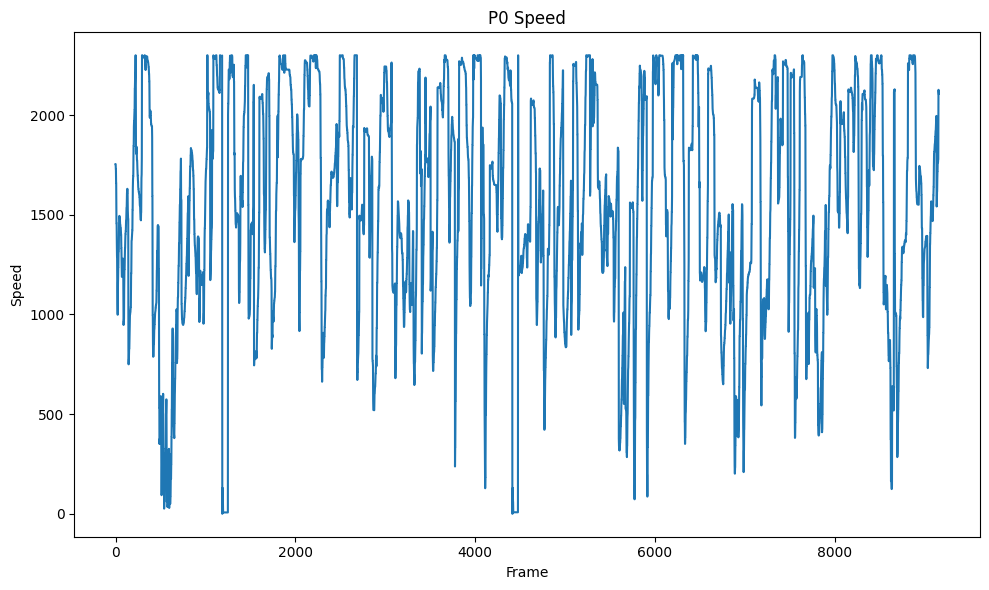

In [92]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(p0_speed)
ax.set_xlabel('Frame')
ax.set_ylabel('Speed')
ax.set_title('P0 Speed')
plt.tight_layout()
plt.show()

## Player Boost

In [75]:
p0_boost = frames['p0_boost level']
p0_boost

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
9152    0.0
9153    0.0
9154    0.0
9155    0.0
9156    0.0
Name: p0_boost level, Length: 9157, dtype: float32

In [80]:
p0_boost.describe()

count    9157.000000
mean      110.377754
std        87.460846
min         0.000000
25%        32.000000
50%        98.662857
75%       191.000000
max       255.000000
Name: p0_boost level, dtype: float64

In [83]:
p0_boost = (p0_boost/p0_boost.max())*100
p0_boost.describe()

count    9157.000000
mean       43.285393
std        34.298370
min         0.000000
25%        12.549021
50%        38.691315
75%        74.901962
max       100.000000
Name: p0_boost level, dtype: float64

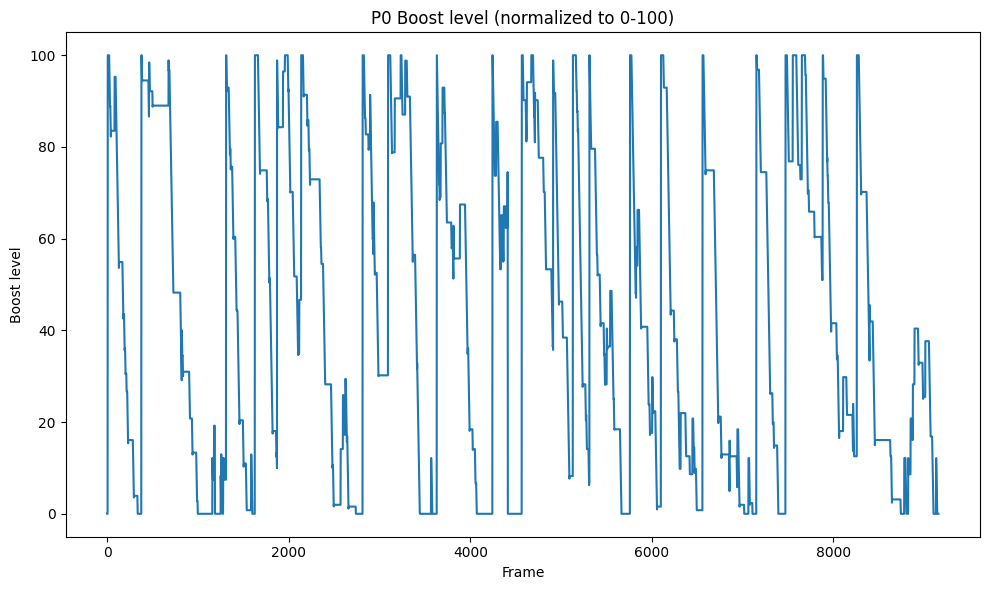

In [85]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(p0_boost)
ax.set_xlabel('Frame')
ax.set_ylabel('Boost level')
ax.set_title('P0 Boost level (normalized to 0-100)')
plt.tight_layout()
plt.show()

## Feature min/max

In [97]:
min_max = frames.agg(['min', 'max'])
min_max.head()

,frame,current time,frame time,seconds remaining,Ball - position x,Ball - position y,Ball - position z,Ball - linear velocity x,Ball - linear velocity y,Ball - linear velocity z,...,p5_angular velocity z,p5_quaternion x,p5_quaternion y,p5_quaternion z,p5_quaternion w,p5_boost level,p5_dodge active,p5_jump active,p5_double jump active,p5_player demolished by
min,0,70.730148,70.743622,0.0,-4007.600098,-5178.169922,79.980003,-3596.560059,-3417.219971,-1948.270020,...,-544.679993,-0.698297,-0.707058,-0.707101,-0.707107,0.0,0.0,0.0,0.0,-1.0
max,9156,407.486298,407.505798,300.0,4003.260010,5103.770020,1960.439941,3042.090088,3306.629883,2337.290039,...,549.369995,0.983055,0.994004,0.999988,1.000000,255.0,66.0,86.0,14.0,-1.0
